# Mutual Information

## Real-World Scenario: Identifying Informative Biomarkers for Cell State Classification

A systems biology lab wants to identify which gene expression markers are most **informative** about cell state in their whole cell model. Mutual information quantifies exactly this: how much knowing a biomarker's value reduces uncertainty about the cell's state.

We cover all of PML Section 6.3: MI definition, information diagrams, MI as a generalized correlation, normalized MI, data processing inequality, Fano's inequality, and the chain rule for MI.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'


def entropy(p):
    """Discrete entropy H(X) = -sum p_k log2 p_k (Eq. 6.1)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def joint_entropy(pxy):
    """Joint entropy H(X,Y) from joint pmf table (Eq. 6.8)."""
    pxy = np.asarray(pxy, dtype=float)
    mask = pxy > 0
    return -np.sum(pxy[mask] * np.log2(pxy[mask]))


def conditional_entropy(pxy):
    """H(Y|X) = H(X,Y) - H(X) (Eq. 6.15)."""
    return joint_entropy(pxy) - entropy(pxy.sum(axis=1))


def mutual_information(pxy):
    """Mutual information I(X; Y) = H(X) + H(Y) - H(X,Y) (Eq. 6.51)."""
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    return entropy(px) + entropy(py) - joint_entropy(pxy)

## Key Formulas from PML Section 6.3

| Concept | Formula | Eq. |
|---------|---------|-----|
| Mutual information | $I(X;Y) = D_{\text{KL}}(p(x,y) \| p(x)p(y))$ | 6.47 |
| MI via entropies | $I(X;Y) = H(X) - H(X \mid Y) = H(X) + H(Y) - H(X,Y)$ | 6.49, 6.51 |
| MI (Gaussian) | $I(X;Y) = -\frac{1}{2}\ln(1 - \rho^2)$ | 6.70 |
| Normalized MI | $\text{NMI} = I(X;Y) / \min(H(X), H(Y))$ | 6.74 |
| Conditional MI | $I(X;Y \mid Z) = H(X \mid Z) - H(X \mid Y,Z)$ | 6.58 |
| Chain rule (MI) | $I(Z_1, \ldots, Z_N; X) = \sum_n I(Z_n; X \mid Z_1, \ldots, Z_{n-1})$ | 6.63 |
| DPI | $X \to Y \to Z \Rightarrow I(X;Y) \geq I(X;Z)$ | Thm 6.3.1 |
| Fano | $P_e \geq (H(Y \mid X) - 1) / \log|\mathcal{Y}|$ | 6.84 |

In [2]:
# Plotting colors and shared data used across this notebook
colors = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350']

# PML even/prime example (Section 6.1.3)
pxy_even_prime = np.array([
    [1/8, 3/8],  # X=0 (not even): (Y=0 not prime, Y=1 prime)
    [3/8, 1/8],  # X=1 (even):     (Y=0 not prime, Y=1 prime)
])

# Biomarker examples
# Good marker: rows = marker level (low/med/high), cols = cell state (quiescent/proliferating/stressed)
pxy_good_marker = np.array([
    [0.30, 0.02, 0.01],
    [0.05, 0.28, 0.04],
    [0.02, 0.03, 0.25],
])

pxy_poor_marker = np.array([
    [0.12, 0.11, 0.10],
    [0.12, 0.12, 0.10],
    [0.11, 0.11, 0.11],
])

# Gene pair joint distributions
joint_dists = {
    'Independent genes': np.array([[0.42, 0.18], [0.28, 0.12]]),
    'Co-activated genes': np.array([[0.45, 0.05], [0.05, 0.45]]),
    'Antagonistic genes': np.array([[0.05, 0.45], [0.45, 0.05]]),
}

## 14. Mutual Information Definition (Section 6.3.1)

The mutual information between $X$ and $Y$ (Eq. 6.47):

$$I(X; Y) = D_{\text{KL}}(p(x,y) \| p(x)p(y)) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$$

Equivalent forms (Eqs. 6.49–6.51):

$$I(X; Y) = H(X) - H(X \mid Y) = H(Y) - H(Y \mid X) = H(X) + H(Y) - H(X,Y)$$

MI is always non-negative ($I(X; Y) \geq 0$) and symmetric ($I(X; Y) = I(Y; X)$).

In [3]:
def mutual_information(pxy):
    """Mutual information I(X; Y) = H(X) + H(Y) - H(X,Y) (Eq. 6.51)."""
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    return entropy(px) + entropy(py) - joint_entropy(pxy)


# Verify: MI = KL between joint and product of marginals
def mi_via_kl(pxy):
    """MI via KL divergence definition (Eq. 6.47)."""
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    mi = 0.0
    for i in range(pxy.shape[0]):
        for j in range(pxy.shape[1]):
            if pxy[i, j] > 0:
                mi += pxy[i, j] * np.log2(pxy[i, j] / (px[i] * py[j]))
    return mi


# PML even/prime example (Section 6.3.3)
print('Even/Prime example (PML Section 6.3.3):')
H_X = entropy(pxy_even_prime.sum(axis=1))
H_Y = entropy(pxy_even_prime.sum(axis=0))
H_XY = joint_entropy(pxy_even_prime)
H_Y_given_X = conditional_entropy(pxy_even_prime)
MI = mutual_information(pxy_even_prime)
MI_kl = mi_via_kl(pxy_even_prime)

print(f'  H(X) = {H_X:.2f}, H(Y) = {H_Y:.2f}, H(X,Y) = {H_XY:.2f}')
print(f'  H(Y|X) = {H_Y_given_X:.2f}')
print(f'  I(X;Y) via entropies = {MI:.4f} bits')
print(f'  I(X;Y) via KL        = {MI_kl:.4f} bits')
print(f'  Verify: H(X,Y) = H(X|Y) + I(X;Y) + H(Y|X) = {H_Y_given_X:.2f} + {MI:.2f} + {H_Y_given_X:.2f} = {H_Y_given_X + MI + H_Y_given_X:.2f}')

Even/Prime example (PML Section 6.3.3):
  H(X) = 1.00, H(Y) = 1.00, H(X,Y) = 1.81
  H(Y|X) = 0.81
  I(X;Y) via entropies = 0.1887 bits
  I(X;Y) via KL        = 0.1887 bits
  Verify: H(X,Y) = H(X|Y) + I(X;Y) + H(Y|X) = 0.81 + 0.19 + 0.81 = 1.81


## 15. Information Diagram (Section 6.3.2)

The relationships between $H(X)$, $H(Y)$, $H(X,Y)$, $H(X|Y)$, $H(Y|X)$, and $I(X;Y)$ are summarized in the information (Venn) diagram (cf. PML Figure 6.4):

$$H(X,Y) = H(X|Y) + I(X;Y) + H(Y|X)$$

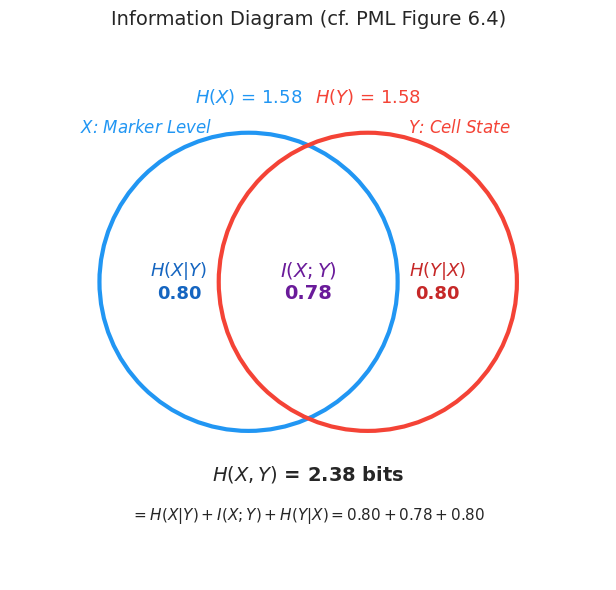

In [4]:
# Information Venn diagram (cf. PML Figure 6.4)
from matplotlib.patches import Circle

# Use the biomarker example
pxy = pxy_good_marker
px = pxy.sum(axis=1)
py = pxy.sum(axis=0)
H_X = entropy(px)
H_Y = entropy(py)
H_XY = joint_entropy(pxy)
H_X_given_Y = joint_entropy(pxy) - entropy(py)
H_Y_given_X = conditional_entropy(pxy)
MI_val = mutual_information(pxy)

fig, ax = plt.subplots(figsize=(10, 6))

# Draw circles
c1 = Circle((-0.6, 0), 1.5, fill=False, edgecolor='#2196F3', linewidth=3, linestyle='-')
c2 = Circle((0.6, 0), 1.5, fill=False, edgecolor='#F44336', linewidth=3, linestyle='-')
ax.add_patch(c1)
ax.add_patch(c2)

# Fill regions
from matplotlib.patches import FancyBboxPatch
ax.text(-1.3, 0, f'$H(X|Y)$\n{H_X_given_Y:.2f}', ha='center', va='center',
        fontsize=13, color='#1565C0', fontweight='bold')
ax.text(0, 0, f'$I(X;Y)$\n{MI_val:.2f}', ha='center', va='center',
        fontsize=14, color='#6A1B9A', fontweight='bold')
ax.text(1.3, 0, f'$H(Y|X)$\n{H_Y_given_X:.2f}', ha='center', va='center',
        fontsize=13, color='#C62828', fontweight='bold')

# Labels
ax.text(-0.6, 1.8, f'$H(X)$ = {H_X:.2f}', ha='center', fontsize=13, color='#2196F3')
ax.text(0.6, 1.8, f'$H(Y)$ = {H_Y:.2f}', ha='center', fontsize=13, color='#F44336')
ax.text(0, -2.0, f'$H(X,Y)$ = {H_XY:.2f} bits', ha='center', fontsize=14, fontweight='bold')
ax.text(0, -2.4, f'$= H(X|Y) + I(X;Y) + H(Y|X) = {H_X_given_Y:.2f} + {MI_val:.2f} + {H_Y_given_X:.2f}$',
        ha='center', fontsize=11)

ax.text(-2.3, 1.5, '$X$: Marker Level', fontsize=12, color='#2196F3', fontstyle='italic')
ax.text(1.0, 1.5, '$Y$: Cell State', fontsize=12, color='#F44336', fontstyle='italic')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 2.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Information Diagram (cf. PML Figure 6.4)', fontsize=14)

plt.tight_layout()
plt.show()

## 16. MI as a Generalized Correlation Coefficient (Section 6.3.5)

For jointly Gaussian $(X, Y)$ with correlation $\rho$ (Eq. 6.70):

$$I(X; Y) = -\frac{1}{2} \ln(1 - \rho^2)$$

Special cases:
- $\rho = 0$: $I = 0$ (independent)
- $|\rho| = 1$: $I = \infty$ (perfect dependence)

Unlike Pearson's correlation, MI captures **nonlinear** dependencies.

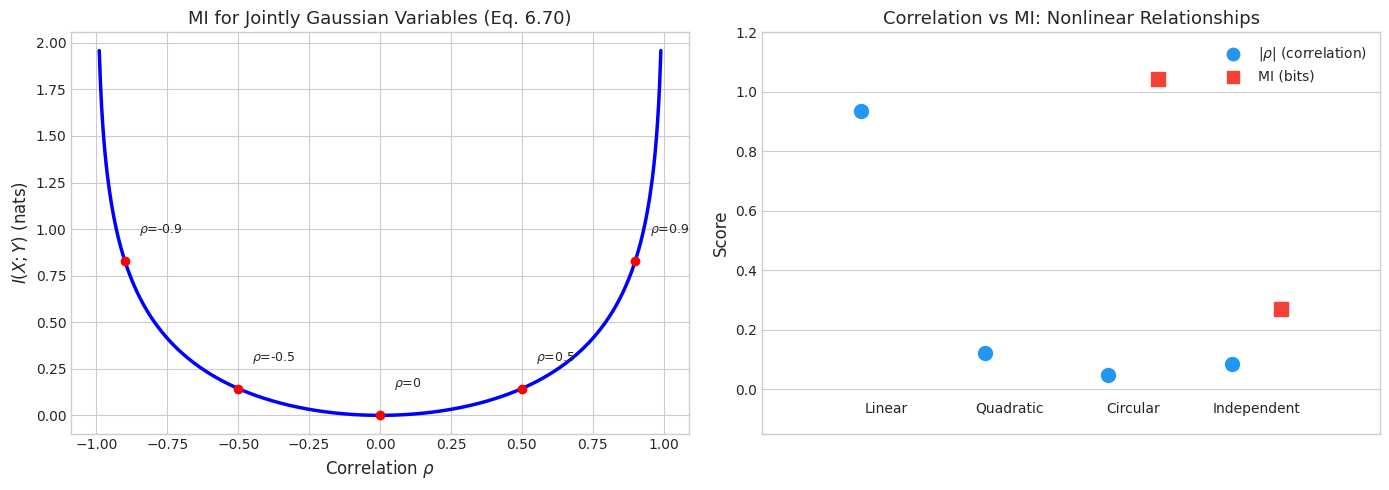

Correlation misses quadratic and circular relationships (|rho| ≈ 0).
MI correctly detects all non-trivial dependencies.


In [5]:
def mi_gaussian(rho):
    """MI for jointly Gaussian variables (Eq. 6.70), in nats."""
    return -0.5 * np.log(1 - rho**2)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MI vs rho
rho_range = np.linspace(-0.99, 0.99, 500)
mi_vals = mi_gaussian(rho_range)

axes[0].plot(rho_range, mi_vals, 'b-', linewidth=2.5)
axes[0].set_xlabel('Correlation $\\rho$', fontsize=12)
axes[0].set_ylabel('$I(X; Y)$ (nats)', fontsize=12)
axes[0].set_title('MI for Jointly Gaussian Variables (Eq. 6.70)', fontsize=13)

# Mark key points
for rho_pt in [0, 0.5, -0.5, 0.9, -0.9]:
    mi_pt = mi_gaussian(rho_pt)
    axes[0].plot(rho_pt, mi_pt, 'ro', markersize=6)
    axes[0].annotate(f'$\\rho$={rho_pt}', xy=(rho_pt, mi_pt),
                    xytext=(rho_pt + 0.05, mi_pt + 0.15), fontsize=9)

# Right: MI captures nonlinear relationships (unlike correlation)
np.random.seed(42)
n = 500

relationships = [
    ('Linear', lambda: (np.random.randn(n), None)),
    ('Quadratic', lambda: (np.random.randn(n), None)),
    ('Circular', lambda: (np.random.randn(n), None)),
    ('Independent', lambda: (np.random.randn(n), np.random.randn(n))),
]

# Generate data for each relationship
x_lin = np.random.randn(n)
y_lin = 0.8 * x_lin + 0.3 * np.random.randn(n)

x_quad = np.random.randn(n)
y_quad = x_quad**2 + 0.3 * np.random.randn(n)

theta_circ = np.random.uniform(0, 2 * np.pi, n)
x_circ = np.cos(theta_circ) + 0.1 * np.random.randn(n)
y_circ = np.sin(theta_circ) + 0.1 * np.random.randn(n)

x_ind = np.random.randn(n)
y_ind = np.random.randn(n)

pairs = [
    ('Linear', x_lin, y_lin),
    ('Quadratic', x_quad, y_quad),
    ('Circular', x_circ, y_circ),
    ('Independent', x_ind, y_ind),
]

# Estimate MI using binning (simple approach from Section 6.3.5)
def estimate_mi_binned(x, y, bins=15):
    """Estimate MI via discretization into a 2D histogram."""
    hist_2d, _, _ = np.histogram2d(x, y, bins=bins)
    pxy = hist_2d / hist_2d.sum()
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    mi = 0.0
    for i in range(bins):
        for j in range(bins):
            if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:
                mi += pxy[i, j] * np.log2(pxy[i, j] / (px[i] * py[j]))
    return mi

axes[1].set_xlim(0, 5)
axes[1].set_ylim(-0.15, 1.2)

for idx, (name, x_data, y_data) in enumerate(pairs):
    corr = np.corrcoef(x_data, y_data)[0, 1]
    mi_est = estimate_mi_binned(x_data, y_data)
    axes[1].scatter(idx + 0.8, abs(corr), c='#2196F3', s=100, marker='o', zorder=5)
    axes[1].scatter(idx + 1.2, mi_est, c='#F44336', s=100, marker='s', zorder=5)
    axes[1].text(idx + 1, -0.08, name, ha='center', fontsize=10)

axes[1].scatter([], [], c='#2196F3', s=80, marker='o', label='$|\\rho|$ (correlation)')
axes[1].scatter([], [], c='#F44336', s=80, marker='s', label='MI (bits)')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Correlation vs MI: Nonlinear Relationships', fontsize=13)
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print('Correlation misses quadratic and circular relationships (|rho| ≈ 0).')
print('MI correctly detects all non-trivial dependencies.')

## 17. Normalized Mutual Information (Section 6.3.6)

Since $0 \leq I(X; Y) \leq \min(H(X), H(Y))$ (Eq. 6.73), we can normalize (Eq. 6.74):

$$\text{NMI}(X, Y) = \frac{I(X; Y)}{\min(H(X), H(Y))} \in [0, 1]$$

NMI = 0 means independence; NMI = 1 means one variable is a deterministic function of the other.

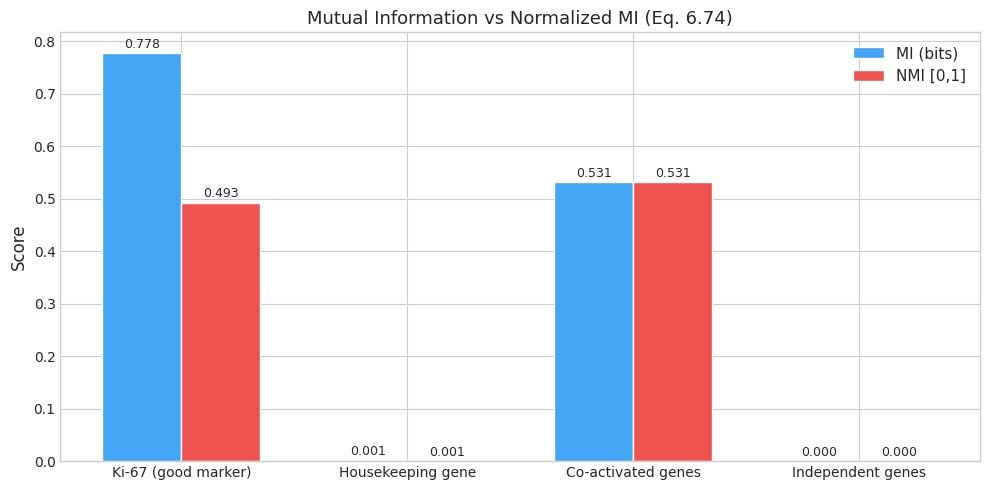

NMI normalizes MI to [0, 1], making it easier to compare across different variable sets.


In [6]:
def normalized_mi(pxy):
    """Normalized MI (Eq. 6.74)."""
    mi = mutual_information(pxy)
    hx = entropy(pxy.sum(axis=1))
    hy = entropy(pxy.sum(axis=0))
    denom = min(hx, hy)
    return mi / denom if denom > 0 else 0.0


# Compare biomarker quality using NMI
biomarkers = {
    'Ki-67 (good marker)': pxy_good_marker,
    'Housekeeping gene': pxy_poor_marker,
    'Co-activated genes': joint_dists['Co-activated genes'],
    'Independent genes': joint_dists['Independent genes'],
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(biomarkers.keys())
mi_vals = [mutual_information(pxy) for pxy in biomarkers.values()]
nmi_vals = [normalized_mi(pxy) for pxy in biomarkers.values()]

x_pos = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x_pos - width/2, mi_vals, width, label='MI (bits)', color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x_pos + width/2, nmi_vals, width, label='NMI [0,1]', color='#EF5350', edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mutual Information vs Normalized MI (Eq. 6.74)', fontsize=13)
ax.legend(fontsize=11)

for bar, val in zip(bars1, mi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
           ha='center', fontsize=9)
for bar, val in zip(bars2, nmi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
           ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('NMI normalizes MI to [0, 1], making it easier to compare across different variable sets.')

## 18. Data Processing Inequality (Section 6.3.8)

**Theorem 6.3.1**: If $X \to Y \to Z$ forms a Markov chain (i.e., $X \perp Z \mid Y$), then:

$$I(X; Y) \geq I(X; Z)$$

Processing data can only **lose** information, never gain it. This is fundamental for understanding why sufficient statistics matter.

**Sufficient statistics** (Section 6.3.9): A statistic $s(D)$ is sufficient for $\theta$ if $I(\theta; s(D)) = I(\theta; D)$ — no information is lost.

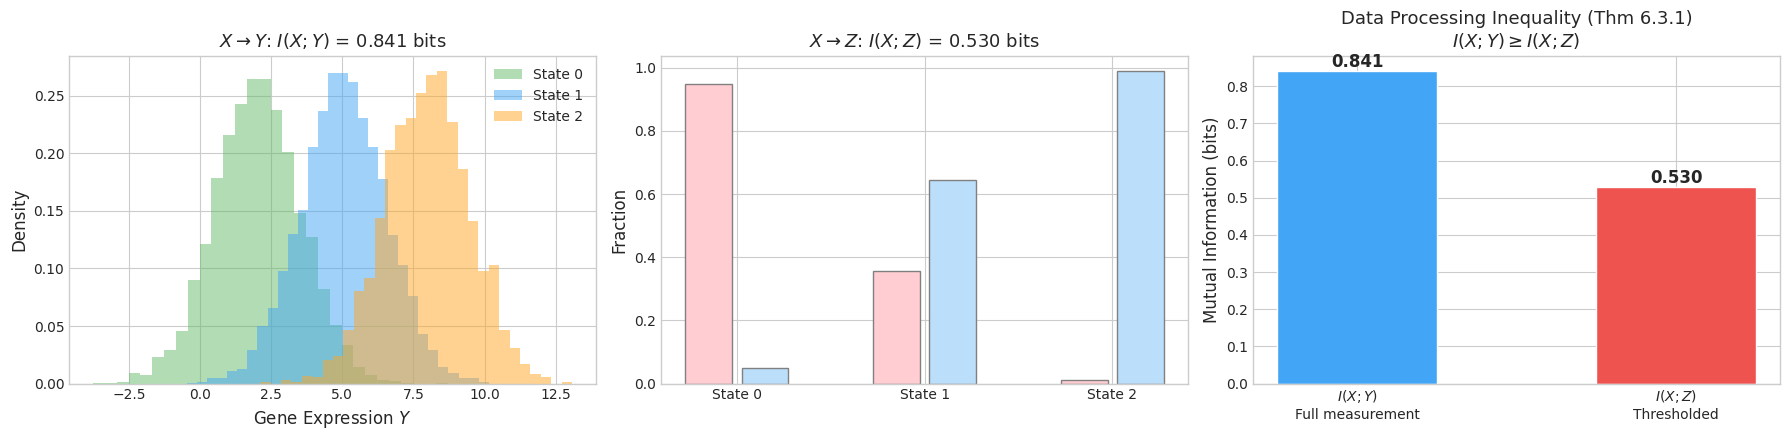

I(X; Y) = 0.841 bits (full continuous measurement)
I(X; Z) = 0.530 bits (binary threshold)
Information lost by thresholding: 0.311 bits

The DPI confirms: processing data (Y → Z) cannot increase information about X.


In [7]:
# Demonstrate DPI: X -> Y -> Z, processing Y into Z loses information about X
# X = true cell state (hidden), Y = gene expression measurement, Z = thresholded binary call

np.random.seed(42)
N_dpi = 10000

# X: true cell state (3 classes)
X = np.random.choice(3, N_dpi, p=[0.4, 0.35, 0.25])

# Y: continuous measurement (noisy function of X)
means = [2.0, 5.0, 8.0]
Y = np.array([np.random.normal(means[x], 1.5) for x in X])

# Z: thresholded binary (lossy processing of Y)
Z = (Y > 4.5).astype(int)

# Discretize Y for MI estimation
Y_binned = np.digitize(Y, bins=np.linspace(Y.min(), Y.max(), 20)) - 1

def empirical_mi(x, y):
    """Estimate MI from discrete samples."""
    joint = np.zeros((x.max() + 1, y.max() + 1))
    for xi, yi in zip(x, y):
        joint[xi, yi] += 1
    joint /= joint.sum()
    return mutual_information(joint)

mi_xy = empirical_mi(X, Y_binned)
mi_xz = empirical_mi(X, Z)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Left: X vs Y
for state in range(3):
    mask = X == state
    axes[0].hist(Y[mask], bins=30, alpha=0.5, density=True,
                label=f'State {state}', color=colors[state])
axes[0].set_xlabel('Gene Expression $Y$', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'$X \\to Y$: $I(X; Y)$ = {mi_xy:.3f} bits', fontsize=13)
axes[0].legend(fontsize=10)

# Middle: X vs Z (thresholded)
for state in range(3):
    mask = X == state
    z_counts = [np.sum(Z[mask] == 0), np.sum(Z[mask] == 1)]
    axes[1].bar([state - 0.15, state + 0.15], z_counts / np.sum(mask),
               width=0.25, color=['#FFCDD2', '#BBDEFB'], edgecolor='gray')

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['State 0', 'State 1', 'State 2'])
axes[1].set_ylabel('Fraction', fontsize=12)
axes[1].set_title(f'$X \\to Z$: $I(X; Z)$ = {mi_xz:.3f} bits', fontsize=13)

# Right: bar chart comparing MI
bars = axes[2].bar(['$I(X; Y)$\nFull measurement', '$I(X; Z)$\nThresholded'],
                   [mi_xy, mi_xz], color=['#42A5F5', '#EF5350'], edgecolor='white', width=0.5)
axes[2].set_ylabel('Mutual Information (bits)', fontsize=12)
axes[2].set_title('Data Processing Inequality (Thm 6.3.1)\n$I(X;Y) \\geq I(X;Z)$', fontsize=13)

for bar, val in zip(bars, [mi_xy, mi_xz]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'I(X; Y) = {mi_xy:.3f} bits (full continuous measurement)')
print(f'I(X; Z) = {mi_xz:.3f} bits (binary threshold)')
print(f'Information lost by thresholding: {mi_xy - mi_xz:.3f} bits')
print('\nThe DPI confirms: processing data (Y → Z) cannot increase information about X.')

## 19. Fano's Inequality (Section 6.3.10)

**Theorem 6.3.2** (Fano's inequality): For any estimator $\hat{Y} = f(X)$ where $Y \to X \to \hat{Y}$, the probability of error $P_e = P(Y \neq \hat{Y})$ is bounded (Eq. 6.84):

$$P_e \geq \frac{H(Y \mid X) - 1}{\log |\mathcal{Y}|}$$

Minimizing $H(Y \mid X)$ (equivalently, maximizing $I(X; Y)$) minimizes this lower bound on error. This justifies using MI for **feature selection**.

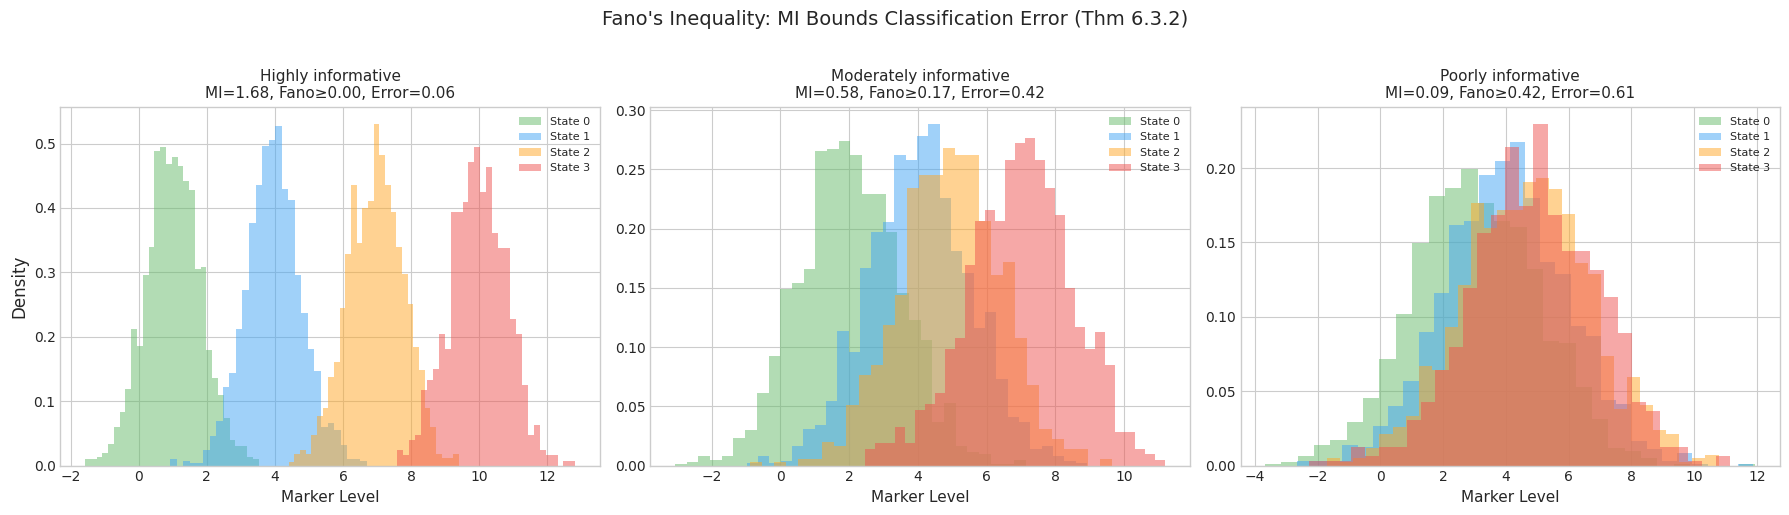

H(Cell State) = 1.922 bits, log₂(K) = 2.000

Marker                           I(X;Y)   H(Y|X)  Fano lb   Actual
-----------------------------------------------------------------
Highly informative                1.682    0.240    0.000    0.055
Moderately informative            0.578    1.344    0.172    0.425
Poorly informative                0.091    1.831    0.416    0.608

Actual error is always above the Fano bound, as guaranteed by the theorem.


In [8]:
# Fano's inequality: bound on classification error
# Compare biomarkers for classifying cell states

K_states = 4  # cell states
log_K = np.log2(K_states)

# Simulate markers with different informativeness
np.random.seed(42)
N_fano = 5000
cell_states = np.random.choice(K_states, N_fano, p=[0.35, 0.30, 0.20, 0.15])

# Marker 1: very informative (distinct means per state)
marker_means_good = [1.0, 4.0, 7.0, 10.0]
marker1 = np.array([np.random.normal(marker_means_good[s], 0.8) for s in cell_states])

# Marker 2: moderately informative
marker_means_med = [2.0, 4.0, 5.0, 7.0]
marker2 = np.array([np.random.normal(marker_means_med[s], 1.5) for s in cell_states])

# Marker 3: poor (overlapping)
marker_means_bad = [3.0, 4.0, 4.5, 5.0]
marker3 = np.array([np.random.normal(marker_means_bad[s], 2.0) for s in cell_states])

markers = [
    ('Highly informative', marker1),
    ('Moderately informative', marker2),
    ('Poorly informative', marker3),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

H_Y = entropy(np.bincount(cell_states) / N_fano)

results = []
for ax, (name, marker) in zip(axes, markers):
    # Discretize marker
    marker_binned = np.digitize(marker, np.linspace(marker.min(), marker.max(), 15)) - 1
    
    # Compute MI and conditional entropy
    mi = empirical_mi(cell_states, marker_binned)
    H_Y_given_X = H_Y - mi
    
    # Fano bound (Eq. 6.84)
    fano_bound = max(0, (H_Y_given_X - 1) / log_K)
    
    # Actual error (simple nearest-mean classifier)
    # Assign each bin to the most common state
    pred = np.zeros(N_fano, dtype=int)
    for b in range(marker_binned.max() + 1):
        mask = marker_binned == b
        if mask.sum() > 0:
            pred[mask] = np.bincount(cell_states[mask], minlength=K_states).argmax()
    actual_error = np.mean(pred != cell_states)
    
    results.append((name, mi, H_Y_given_X, fano_bound, actual_error))
    
    # Plot
    for s in range(K_states):
        mask = cell_states == s
        ax.hist(marker[mask], bins=30, alpha=0.5, density=True,
               label=f'State {s}', color=colors[s % len(colors)])
    
    ax.set_xlabel('Marker Level', fontsize=11)
    ax.set_title(f'{name}\nMI={mi:.2f}, Fano≥{fano_bound:.2f}, Error={actual_error:.2f}', fontsize=11)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Density', fontsize=12)
plt.suptitle("Fano's Inequality: MI Bounds Classification Error (Thm 6.3.2)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'H(Cell State) = {H_Y:.3f} bits, log₂(K) = {log_K:.3f}\n')
print(f'{"Marker":30s} {"I(X;Y)":>8s} {"H(Y|X)":>8s} {"Fano lb":>8s} {"Actual":>8s}')
print('-' * 65)
for name, mi, hyx, fano, actual in results:
    print(f'{name:30s} {mi:8.3f} {hyx:8.3f} {fano:8.3f} {actual:8.3f}')
print('\nActual error is always above the Fano bound, as guaranteed by the theorem.')

## 20. Conditional Mutual Information and Chain Rule (Section 6.3.4)

The conditional MI (Eq. 6.58):

$$I(X; Y \mid Z) = H(X \mid Z) + H(Y \mid Z) - H(X, Y \mid Z)$$

This measures the **residual** information $X$ tells us about $Y$ beyond what $Z$ already revealed (Eq. 6.61):

$$I(X; Y \mid Z) = I(Y; X, Z) - I(Y; Z)$$

**Chain rule for MI** (Eq. 6.63):

$$I(Z_1, \ldots, Z_N; X) = \sum_{n=1}^{N} I(Z_n; X \mid Z_1, \ldots, Z_{n-1})$$

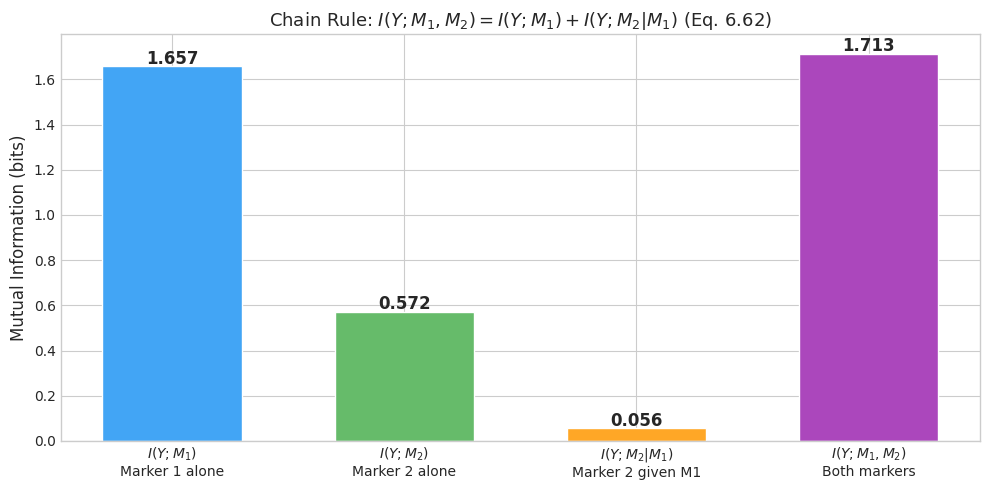

I(Y; M1)           = 1.657 bits
I(Y; M2)           = 0.572 bits
I(Y; M2 | M1)      = 0.056 bits  (residual info beyond M1)
I(Y; M1, M2)       = 1.713 bits
Chain rule check: 1.657 + 0.056 = 1.713 ≈ 1.713

Marker 2 provides 0.056 bits of NEW information beyond Marker 1.
This is less than its standalone MI (0.572) because the markers are partially redundant.


In [9]:
# Demonstrate conditional MI: incremental value of biomarkers
# After observing marker 1, how much MORE does marker 2 tell us about cell state?

# Discretize both markers
m1_binned = np.digitize(marker1, np.linspace(marker1.min(), marker1.max(), 12)) - 1
m2_binned = np.digitize(marker2, np.linspace(marker2.min(), marker2.max(), 12)) - 1
m3_binned = np.digitize(marker3, np.linspace(marker3.min(), marker3.max(), 12)) - 1

# I(Y; M1) — information from marker 1 alone
mi_y_m1 = empirical_mi(cell_states, m1_binned)

# I(Y; M2) — information from marker 2 alone
mi_y_m2 = empirical_mi(cell_states, m2_binned)

# I(Y; M1, M2) — joint information from both markers
m12_combined = m1_binned * (m2_binned.max() + 1) + m2_binned
mi_y_m12 = empirical_mi(cell_states, m12_combined)

# I(Y; M2 | M1) = I(Y; M1, M2) - I(Y; M1) (chain rule, Eq. 6.62)
cmi_y_m2_given_m1 = mi_y_m12 - mi_y_m1

fig, ax = plt.subplots(figsize=(10, 5))

labels = ['$I(Y; M_1)$\nMarker 1 alone',
          '$I(Y; M_2)$\nMarker 2 alone',
          '$I(Y; M_2 | M_1)$\nMarker 2 given M1',
          '$I(Y; M_1, M_2)$\nBoth markers']
values = [mi_y_m1, mi_y_m2, cmi_y_m2_given_m1, mi_y_m12]
bar_colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

bars = ax.bar(labels, values, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
           f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Mutual Information (bits)', fontsize=12)
ax.set_title('Chain Rule: $I(Y; M_1, M_2) = I(Y; M_1) + I(Y; M_2 | M_1)$ (Eq. 6.62)', fontsize=13)

plt.tight_layout()
plt.show()

print(f'I(Y; M1)           = {mi_y_m1:.3f} bits')
print(f'I(Y; M2)           = {mi_y_m2:.3f} bits')
print(f'I(Y; M2 | M1)      = {cmi_y_m2_given_m1:.3f} bits  (residual info beyond M1)')
print(f'I(Y; M1, M2)       = {mi_y_m12:.3f} bits')
print(f'Chain rule check: {mi_y_m1:.3f} + {cmi_y_m2_given_m1:.3f} = {mi_y_m1 + cmi_y_m2_given_m1:.3f} ≈ {mi_y_m12:.3f}')
print(f'\nMarker 2 provides {cmi_y_m2_given_m1:.3f} bits of NEW information beyond Marker 1.')
print(f'This is less than its standalone MI ({mi_y_m2:.3f}) because the markers are partially redundant.')

## Summary

- **Mutual information** $I(X;Y) = H(X) - H(X|Y) \geq 0$ measures the reduction in uncertainty about $X$ after observing $Y$
- MI is **symmetric** and captures all dependencies (including nonlinear), unlike correlation
- The **information diagram** visualizes $H(X,Y) = H(X|Y) + I(X;Y) + H(Y|X)$
- For **jointly Gaussian** variables: $I(X;Y) = -\frac{1}{2}\ln(1 - \rho^2)$
- **Normalized MI** maps to $[0, 1]$ for easy comparison across variable sets
- **Data processing inequality**: $X \to Y \to Z \Rightarrow I(X;Y) \geq I(X;Z)$ — processing only loses info
- **Fano's inequality** bounds classification error using MI — justifies MI-based feature selection
- **Conditional MI** and the chain rule decompose joint information into incremental contributions